# Multiple Q-learning on Dynamic Treatement Regimes : a cancer simulation case study

In [5]:
# ----------------------------------------------------------
# Librairies
# ----------------------------------------------------------

import numpy as np
import pandas as pd
import sys, time, random
import matplotlib.pyplot as plt
import os
import time
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------
# Repro
# ----------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------------------------------------
# Imports
# ----------------------------------------------------------
sys.path.append("scripts")

import DTR_Cancer_DataGeneration as gen
from DTR_Cancer_DataGeneration import (
    generate_dataset,
    calculate_rewards,
    create_data_stage_frames,
    constant_dose_regimes,
    generate_patient_trajectory
)

from NearEquivalentQlearning import NearEquivalentQlearning, classicalQlearning

In [6]:
# ----------------------------------------------------------
# Config 
# ----------------------------------------------------------
N_train = 500
N_traj  = 5000

T_final = 6
number_of_decision = 5  # stages 0..5

possibles_treatments = np.round(np.arange(0.1, 1.1, 0.1), 1)

# ----------------------------------------------------------
# Helpers
# ----------------------------------------------------------
def stagewise_standardize_numeric_only(data_stages_raw: dict, max_stage: int):
    data_stages_scaled = {}
    stage_scalers = {}
    for k in range(max_stage + 1):
        key = f"Data_Stage_{k}"
        Xk = data_stages_raw[key].copy()
        num_cols = Xk.select_dtypes(include=[np.number]).columns.tolist()
        scaler = StandardScaler()
        Xk[num_cols] = scaler.fit_transform(Xk[num_cols])
        data_stages_scaled[key] = Xk
        stage_scalers[k] = scaler
    return data_stages_scaled, stage_scalers

def get_stage_model(models_by_stage, stage: int, policy_index: int):
    """
    Stage 0..4 : list[SVR]
    Stage 5    : single SVR
    """
    m = models_by_stage[stage]
    if isinstance(m, list):
        idx = min(policy_index, len(m) - 1)
        return m[idx]
    return m

def build_policy_Qs_from_models(models_by_stage, policy_index: int):
    return (
        get_stage_model(models_by_stage, 0, policy_index),
        get_stage_model(models_by_stage, 1, policy_index),
        get_stage_model(models_by_stage, 2, policy_index),
        get_stage_model(models_by_stage, 3, policy_index),
        get_stage_model(models_by_stage, 4, policy_index),
        get_stage_model(models_by_stage, 5, policy_index),
    )

In [7]:
# ----------------------------------------------------------
# Data + rewards
# ----------------------------------------------------------
t_block = time.perf_counter()

Data_raw, Remission_Informations, Dead_Informations = generate_dataset(N=N_train)

Rewards_Zhao = calculate_rewards(
    Data_raw,
    Remission_Informations,
    Dead_Informations,
    T_final=T_final
)

for k in range(number_of_decision + 1):
    assert f"Reward_{k}" in Rewards_Zhao.columns

# ----------------------------------------------------------
# Stage datasets 0..T
# ----------------------------------------------------------
data_stages_raw = create_data_stage_frames(Data_raw, number_of_decision)
for k in range(number_of_decision + 1):
    assert f"Data_Stage_{k}" in data_stages_raw

data_stages, stage_scalers = stagewise_standardize_numeric_only(
    data_stages_raw, number_of_decision
)
gen.STAGE_SCALERS = stage_scalers

# ----------------------------------------------------------
# Train classical (opt) ONCE
# ----------------------------------------------------------
t0 = time.perf_counter()
Q0_opt, Q1_opt, Q2_opt, Q3_opt, Q4_opt, Q5_opt = classicalQlearning(
    number_of_decision,
    data_stages,
    Rewards_Zhao,
    possibles_treatments
)
t_classical = time.perf_counter() - t0

# ----------------------------------------------------------
# Train near-equivalent models for multiple eps (ONCE per eps)
# ----------------------------------------------------------
eps_list = [0.1, 0.3, 0.5, 0.9]
models_by_eps = {}
K_by_eps = {}
t_neq = {}

for eps in eps_list:
    t0 = time.perf_counter()
    models_by_stage_eps = NearEquivalentQlearning(
        number_of_decision,
        data_stages,
        Rewards_Zhao,
        possibles_treatments,
        epsilon_selection=eps
    )
    t_neq[eps] = time.perf_counter() - t0

    models_by_eps[eps] = models_by_stage_eps
    K_by_eps[eps] = len(models_by_stage_eps[number_of_decision - 1])

maxK = max(K_by_eps.values())

# ----------------------------------------------------------
# Backward compatibility: keep models_by_stage, K for a chosen epsilon_selection
# ----------------------------------------------------------
if "epsilon_selection" in globals():
    eps0 = float(epsilon_selection)
    if eps0 in models_by_eps:
        models_by_stage = models_by_eps[eps0]
        K = K_by_eps[eps0]
    else:
        eps0_closest = min(eps_list, key=lambda e: abs(e - eps0))
        models_by_stage = models_by_eps[eps0_closest]
        K = K_by_eps[eps0_closest]
        print(f"[warn] epsilon_selection={eps0} not in {eps_list}, using closest eps={eps0_closest}")
else:
    epsilon_selection = eps_list[0]
    models_by_stage = models_by_eps[epsilon_selection]
    K = K_by_eps[epsilon_selection]

# ----------------------------------------------------------
# Print timing summary
# ----------------------------------------------------------
print("\n=== TRAIN TIMES (seconds) ===")
print(f"classicalQlearning : {t_classical:.3f}s")
for eps in eps_list:
    print(f"NEQ eps={eps:<3}       : {t_neq[eps]:.3f}s   (K={K_by_eps[eps]})")
print(f"maxK across eps    : {maxK}")
print(f"total block time   : {time.perf_counter() - t_block:.3f}s\n")


=== TRAIN TIMES (seconds) ===
classicalQlearning : 0.287s
NEQ eps=0.1       : 2.126s   (K=10)
NEQ eps=0.3       : 2.187s   (K=10)
NEQ eps=0.5       : 2.147s   (K=10)
NEQ eps=0.9       : 2.120s   (K=10)
maxK across eps    : 10
total block time   : 10.438s




=== ROLLOUT TIMES per eps (seconds) ===
eps=0.1  const=164.876s  classic=252.823s  M=2601.550s  total=3019.249s  (K=10)
eps=0.3  const=169.730s  classic=284.118s  M=2714.849s  total=3168.700s  (K=10)
eps=0.5  const=160.512s  classic=260.754s  M=2665.065s  total=3086.334s  (K=10)
eps=0.9  const=156.120s  classic=252.467s  M=2600.411s  total=3009.000s  (K=10)



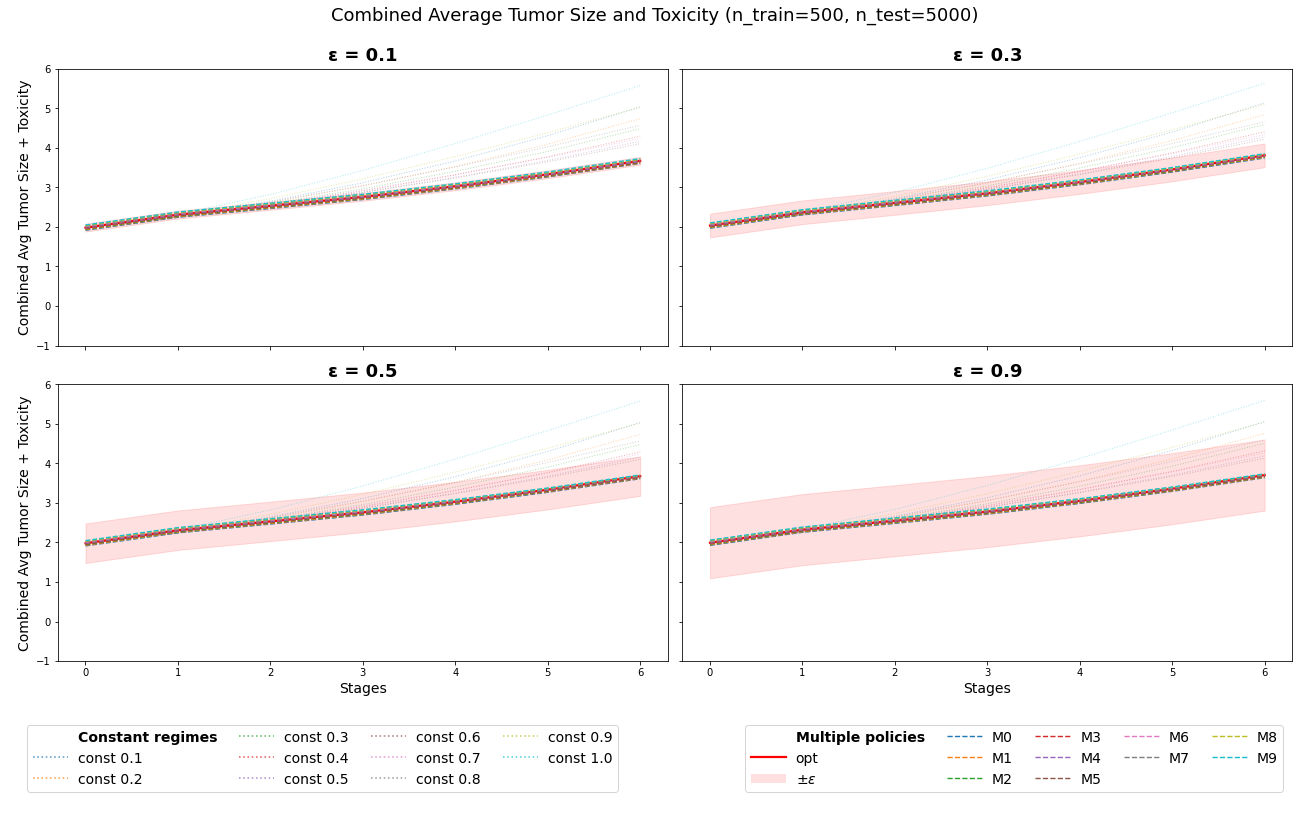

In [8]:
# ==========================================================
# ROLLOUT + PLOT (per-eps blocks)
# For each eps:
#   - sample a fresh test set (Y0s, X0s) ONCE
#   - rollout CONSTANT + CLASSICAL + M policies on that SAME test set
# This ensures identical initial conditions within each eps panel.
# Prints rollout times per eps.
# ==========================================================

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

eps_list = [0.1, 0.3, 0.5, 0.9]

# ----------------------------------------------------------
# Stable time grid length (use ONE trajectory just to define n_points)
# ----------------------------------------------------------
Y0_test = np.random.uniform(0, 2)
X0_test = np.random.uniform(0, 2)
ty, tx = generate_patient_trajectory(
    Q0_opt, Q1_opt, Q2_opt, Q3_opt, Q4_opt, Q5_opt,
    Y0_test, X0_test, possibles_treatments
)
n_points = len(ty)
time_grid = np.arange(n_points)

# ----------------------------------------------------------
# Storage: per-eps results
# ----------------------------------------------------------
mean_const_by_eps = {}    # eps -> {dose -> mean curve}
opt_values_by_eps = {}    # eps -> mean classical curve
mean_M_by_eps = {}        # eps -> {M0.. -> mean curve}
roll_times = {}           # eps -> dict of timings

# ----------------------------------------------------------
# Rollout per eps (each eps has its own test set)
# ----------------------------------------------------------
for eps in eps_list:
    t_eps = time.perf_counter()

    # Same initial states WITHIN this eps
    Y0s = np.random.uniform(0, 2, size=N_traj)
    X0s = np.random.uniform(0, 2, size=N_traj)

    # ---- constants
    t0 = time.perf_counter()
    sum_const = {d: np.zeros(n_points) for d in possibles_treatments}
    for Y0, X0 in zip(Y0s, X0s):
        for d in possibles_treatments:
            ty_c, tx_c = constant_dose_regimes(d, Y0, X0, T_final)
            sum_const[d] += (np.asarray(ty_c) + np.asarray(tx_c))
    mean_const_by_eps[eps] = {d: v / N_traj for d, v in sum_const.items()}
    t_const = time.perf_counter() - t0

    # ---- classical (opt curve)
    t0 = time.perf_counter()
    sum_opt = np.zeros(n_points)
    for Y0, X0 in zip(Y0s, X0s):
        y_opt, x_opt = generate_patient_trajectory(
            Q0_opt, Q1_opt, Q2_opt, Q3_opt, Q4_opt, Q5_opt,
            Y0, X0, possibles_treatments
        )
        sum_opt += (np.asarray(y_opt) + np.asarray(x_opt))
    opt_values_by_eps[eps] = sum_opt / N_traj
    t_opt = time.perf_counter() - t0

    # ---- M policies for this eps (models already trained!)
    t0 = time.perf_counter()
    models_by_stage_eps = models_by_eps[eps]
    K_eps = K_by_eps[eps]

    sum_M = {f"M{m}": np.zeros(n_points) for m in range(K_eps)}
    for Y0, X0 in zip(Y0s, X0s):
        for m in range(K_eps):
            Qs = build_policy_Qs_from_models(models_by_stage_eps, m)
            y_m, x_m = generate_patient_trajectory(
                *Qs, Y0, X0, possibles_treatments
            )
            sum_M[f"M{m}"] += (np.asarray(y_m) + np.asarray(x_m))

    mean_M_by_eps[eps] = {k: v / N_traj for k, v in sum_M.items()}
    t_M = time.perf_counter() - t0

    roll_times[eps] = {
        "constants": t_const,
        "classical": t_opt,
        "M": t_M,
        "total": time.perf_counter() - t_eps,
        "K": K_eps
    }

print("\n=== ROLLOUT TIMES per eps (seconds) ===")
for eps in eps_list:
    rt = roll_times[eps]
    print(f"eps={eps:<3}  const={rt['constants']:.3f}s  classic={rt['classical']:.3f}s  "
          f"M={rt['M']:.3f}s  total={rt['total']:.3f}s  (K={rt['K']})")
print("")

# ----------------------------------------------------------
# Plot settings: consistent colors for M across panels
# ----------------------------------------------------------
maxK = max(K_by_eps.values())
m_cmap = plt.get_cmap("tab10")
m_colors = {m: m_cmap(m % 10) for m in range(maxK)}

# ----------------------------------------------------------
# Plot: 4 panels
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.ravel()

# store constant colors from first panel so legend matches
const_color_map = {}

for idx, eps in enumerate(eps_list):
    ax = axes[idx]
    K_eps = K_by_eps[eps]
    mean_const = mean_const_by_eps[eps]
    opt_values = opt_values_by_eps[eps]
    mean_M = mean_M_by_eps[eps]

    # constants
    for d in possibles_treatments:
        ln, = ax.plot(time_grid, mean_const[d], ':', alpha=0.35, linewidth=1, zorder=3)
        if idx == 0:
            const_color_map[d] = ln.get_color()

    # classical + ribbon
    ax.plot(time_grid, opt_values, 'r-', linewidth=2.2, zorder=4)
    ax.fill_between(time_grid, opt_values - eps, opt_values + eps, color='red', alpha=0.12, zorder=1)

    # M curves (consistent color + tiny offsets)
    eps_display = 0.015
    for m in range(K_eps):
        values = mean_M[f"M{m}"]
        delta = (m - (K_eps - 1) / 2) * eps_display
        ax.plot(time_grid, values + delta, '--', linewidth=1.3, color=m_colors[m], zorder=4)

    ax.set_ylim([-1, 6])
    ax.set_title(f"ε = {eps}", fontsize=18, fontweight="bold", pad=8)
    if idx in (2, 3):
        ax.set_xlabel("Stages", fontsize=14)
    if idx in (0, 2):
        ax.set_ylabel("Combined Avg Tumor Size + Toxicity", fontsize=14)

fig.suptitle(
    f"Combined Average Tumor Size and Toxicity (n_train={N_train}, n_test={N_traj})",
    fontsize=18,
    y=0.95
)

# ----------------------------------------------------------
# Legend band (compact, two blocks)
# ----------------------------------------------------------
h_title_const = Line2D([], [], linestyle='None', label='Constant regimes')
h_title_model = Line2D([], [], linestyle='None', label='Multiple policies')

const_handles = [
    Line2D([], [], linestyle=':', linewidth=1.6, alpha=0.7,
           color=const_color_map.get(d, None),
           label=f"const {d:.1f}")
    for d in possibles_treatments
]
const_labels = [h.get_label() for h in const_handles]

h_opt = Line2D([], [], color='r', linestyle='-', linewidth=2.2, label='opt')
h_rib = Patch(facecolor='red', alpha=0.12, label=r'$\pm \epsilon$')

M_handles = [
    Line2D([], [], linestyle='--', linewidth=1.4, color=m_colors[m], label=f"M{m}")
    for m in range(maxK)
]
M_labels = [h.get_label() for h in M_handles]

plt.tight_layout(rect=[0, 0.14, 1, 0.95])

legend_ax = fig.add_axes([0.00, 0.00, 1.00, 0.13])
legend_ax.axis("off")

# LEFT
left_handles = [h_title_const] + const_handles
left_labels  = ["Constant regimes"] + const_labels
leg_left = legend_ax.legend(
    left_handles, left_labels,
    ncol=4,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    fontsize=14,
    frameon=True,
    handlelength=2.5,
    columnspacing=1.6,
    handletextpad=0.7
)
for t in leg_left.get_texts():
    if t.get_text() == "Constant regimes":
        t.set_weight("bold")
legend_ax.add_artist(leg_left)

# RIGHT
right_handles = [h_title_model, h_opt, h_rib] + M_handles
right_labels  = ["Multiple policies", "opt", r"$\pm \epsilon$"] + M_labels
leg_right = legend_ax.legend(
    right_handles, right_labels,
    ncol=5,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.98),
    fontsize=14,
    frameon=True,
    handlelength=2.5,
    columnspacing=1.6,
    handletextpad=0.7
)
for t in leg_right.get_texts():
    if t.get_text() == "Multiple policies":
        t.set_weight("bold")

# Save + show
outname = (
    f"results/combined_average_tumor_size_and_toxicity_"
    f"epsilon_grid_nTrain{N_train}_nTest{N_traj}.png"
)
os.makedirs("results", exist_ok=True)
fig.savefig(outname, dpi=300, bbox_inches="tight")
plt.show()